In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
%reload_ext autoreload

In [14]:
import pickle as pkl
import numpy as np
from torch.utils.data import DataLoader, random_split

from plots import *
from utils import *
from dataset import *
from vae import *

In [3]:
#on runai
with open('/mydata/cope/mirco/data/ssp585_time_series.pkl', 'rb') as f:
    cope_data = pkl.load(f)

FileNotFoundError: [Errno 2] No such file or directory: '/mydata/cope/mirco/data/ssp585_time_series.pkl'

In [3]:
#on local
with open('cope_data/ssp585_time_series.pkl', 'rb') as f:
    cope_data = pkl.load(f)

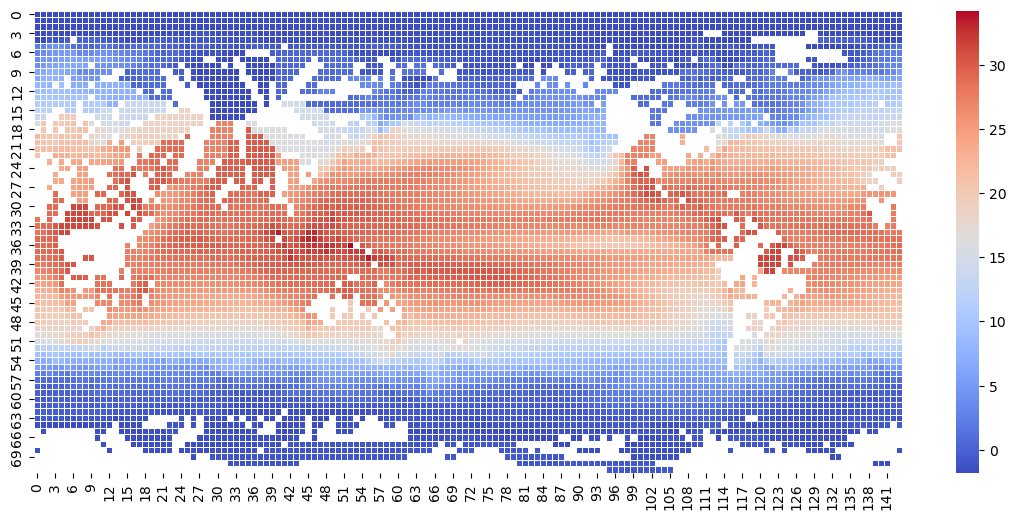

In [4]:
plot_heatmap(cope_data, 'ICON-ESM-LR', 'r1i1p1f1', 1980)

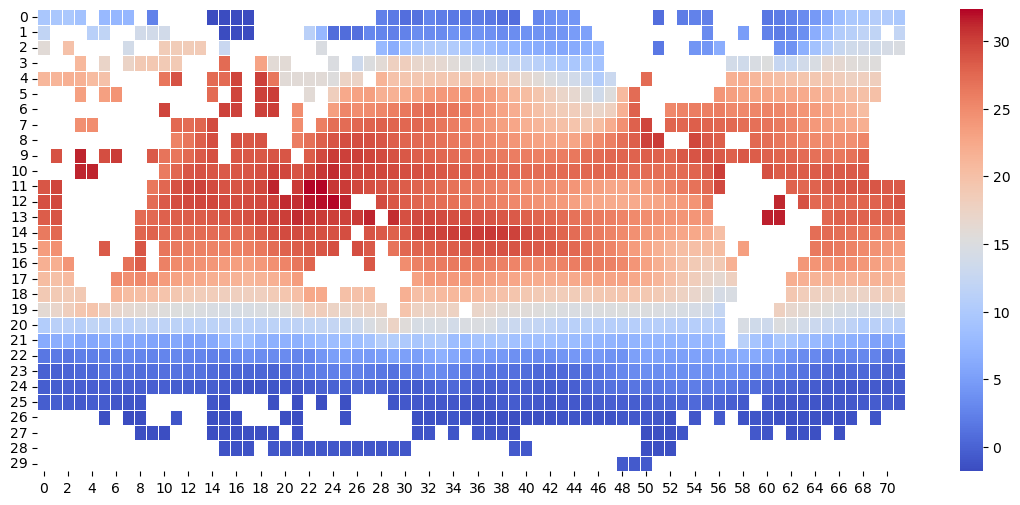

In [5]:
prune(cope_data, min_runs=5)
cut_lat(cope_data, max_lat=60)
downscale(cope_data)

plot_heatmap(cope_data, 'ICON-ESM-LR', 'r1i1p1f1', 1980)

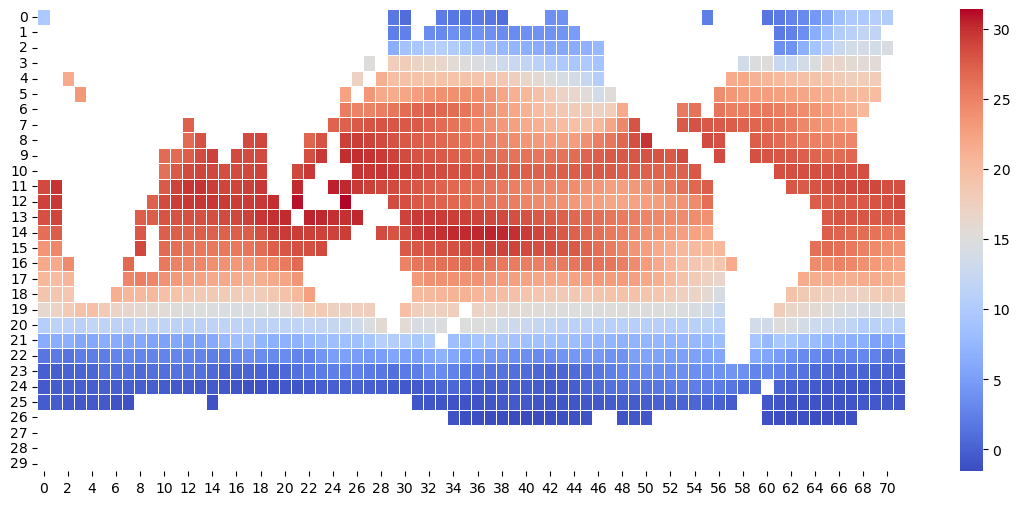

In [6]:
union_nan_mask = find_union_nan_mask(cope_data)
inpute(cope_data, union_nan_mask)

plot_heatmap(cope_data, 'ICON-ESM-LR', 'r1i1p1f1', 1980)

In [7]:
np.array(cope_data['ICON-ESM-LR']['r1i1p1f1']).shape

(165, 30, 72)

In [8]:
X, Y = extract_per_timeserie(cope_data, union_nan_mask, r=[-10, 10])
print(X.shape, Y.shape)

(612, 44472) (612, 44472)


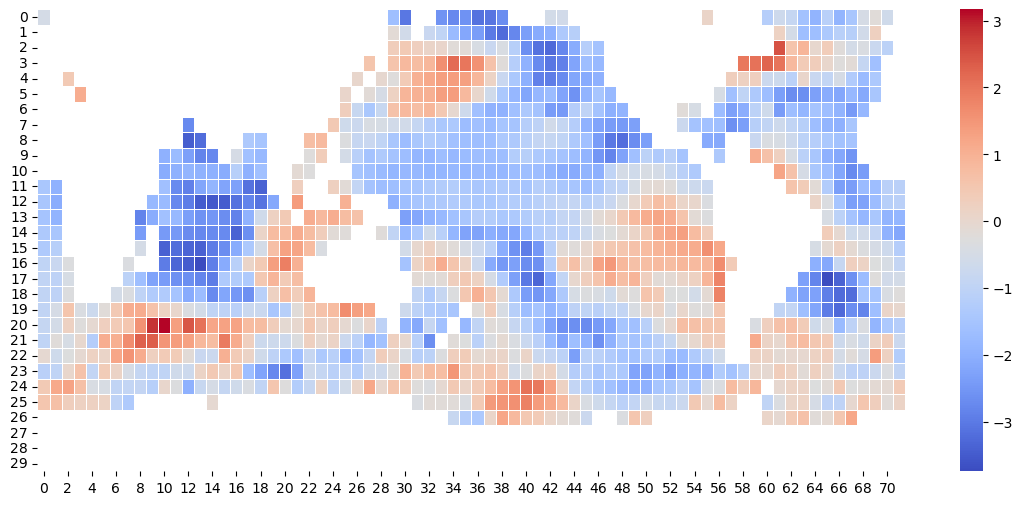

In [17]:
grid_timeserie = from_flat_to_grid_timeserie(X[0], union_nan_mask)
grid_timeserie.shape
plot_grid(grid_timeserie[1])

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [9]:
batch_size = 16

cope_dataset = CopeDataset(samples=X, labels=Y)

train_dataset, test_dataset = random_split(cope_dataset, [0.8, 0.2])

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [10]:
lr = 2e-3
epochs = 30

model = basic_VAE(input_dim=44472, hidden_dim=500, latent_dim=100).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)


print("Start training basic VAE...")
model.train()

for epoch in range(epochs):
    overall_loss = 0
    for batch_idx, (x, y) in enumerate(train_dataloader):
        x = x.to(device)

        optimizer.zero_grad()

        x_hat, mean, logvar = model(x)
        loss = model.loss(x_hat, y, mean, logvar)
        
        overall_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
    print("Epoch", epoch + 1, "complete !", "\tAverage Loss: ", overall_loss / (batch_idx*batch_size))
    
print("Finish!!")

Start training basic VAE...
Epoch 1 complete ! 	Average Loss:  321901.5789713542
Epoch 2 complete ! 	Average Loss:  10219.731070963542
Epoch 3 complete ! 	Average Loss:  8532.435579427083
Epoch 4 complete ! 	Average Loss:  7741.470686848958
Epoch 5 complete ! 	Average Loss:  7458.489111328125
Epoch 6 complete ! 	Average Loss:  7267.478100585938
Epoch 7 complete ! 	Average Loss:  7149.271402994792
Epoch 8 complete ! 	Average Loss:  7056.376546223958
Epoch 9 complete ! 	Average Loss:  6974.265462239583
Epoch 10 complete ! 	Average Loss:  6911.788151041666


KeyboardInterrupt: 

In [13]:
model.eval()

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_dataloader):
        x = x.to(device)
        x_hat, _, _ = model(x)

        break

In [11]:
lr = 1e-3
epochs = 30

model = VAE(input_dim=44472, hidden_dim=500, latent_dim=100).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

print("Start training VAE...")
model.train()

for epoch in range(epochs):
    overall_loss = 0
    for batch_idx, (x, y) in enumerate(train_dataloader):
        x = x.to(device)

        optimizer.zero_grad()

        x_hat, mean, var = model(x)
        loss = model.loss(x_hat, y, mean, var)
        
        overall_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
    print("Epoch", epoch + 1, "complete !", "\tAverage Loss: ", overall_loss / (batch_idx*batch_size))
    
print("Finish!!")

Start training VAE...
Epoch 1 complete ! 	Average Loss:  8561.457250976562
Epoch 2 complete ! 	Average Loss:  4788.676188151042
Epoch 3 complete ! 	Average Loss:  4803.903068033854
Epoch 4 complete ! 	Average Loss:  5030.197599283854
Epoch 5 complete ! 	Average Loss:  4703.0616984049475
Epoch 6 complete ! 	Average Loss:  3981.6687255859374
Epoch 7 complete ! 	Average Loss:  3321.7409505208334
Epoch 8 complete ! 	Average Loss:  2660.4143961588543
Epoch 9 complete ! 	Average Loss:  2395.431221516927
Epoch 10 complete ! 	Average Loss:  2180.632560221354
Epoch 11 complete ! 	Average Loss:  1978.5706197102866
Epoch 12 complete ! 	Average Loss:  1815.0100545247396
Epoch 13 complete ! 	Average Loss:  1748.0822143554688
Epoch 14 complete ! 	Average Loss:  1710.958829752604
Epoch 15 complete ! 	Average Loss:  1668.323856608073
Epoch 16 complete ! 	Average Loss:  1659.8543986002603
Epoch 17 complete ! 	Average Loss:  1657.018416341146
Epoch 18 complete ! 	Average Loss:  1637.6306437174478
Epoch 

In [12]:
model.eval()

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_dataloader):
        x = x.to(device)
        x_hat, _, _ = model(x)
        x_hat.detach()

        break

In [13]:
print(x.shape)
print(x_hat.shape)
print(y.shape)

torch.Size([16, 44472])
torch.Size([16, 44472])
torch.Size([16, 44472])


In [14]:
x, x_hat, y = x.numpy(), x_hat.numpy(), y.numpy()

5.265011 -4.6404276


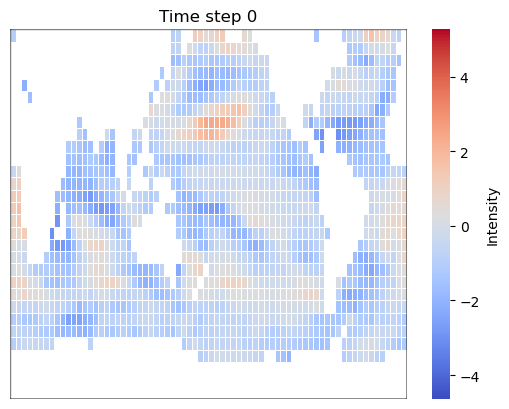

In [15]:
from plots import get_animated_timeserie

a = get_animated_timeserie(x[0], union_nan_mask)
a.save('x.gif', writer='pillow', fps=1)

C:\Users\mirco\AppData\Local\Temp\ipykernel_10744\1817344449.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  a = get_animated_timeserie(np.array(x_hat[0]), union_nan_mask)


2.3774114 -2.0995712


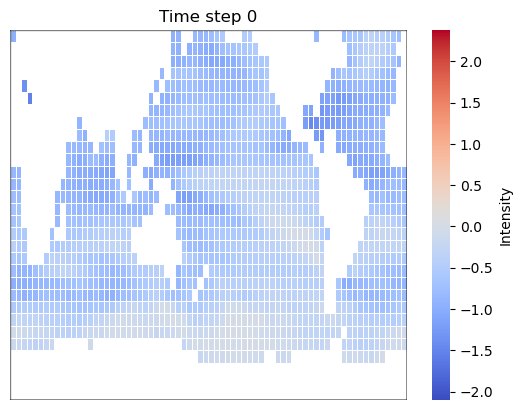

In [37]:
from plots import get_animated_timeserie

a = get_animated_timeserie(x_hat[0], union_nan_mask)
a.save('x_hat.gif', writer='pillow', fps=1)

C:\Users\mirco\AppData\Local\Temp\ipykernel_10744\3833773037.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  a = get_animated_timeserie(np.array(y[0]), union_nan_mask)


2.6262555 -2.6271024


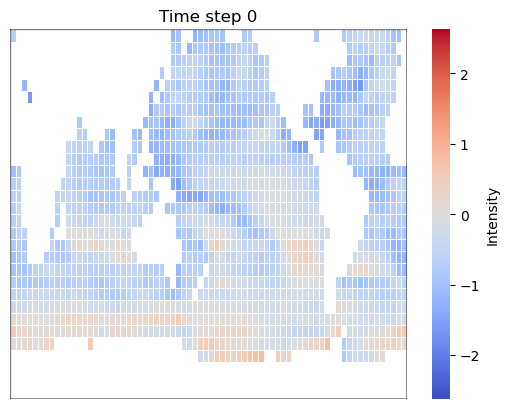

In [38]:
from plots import get_animated_timeserie

a = get_animated_timeserie(y[0], union_nan_mask)
a.save('y.gif', writer='pillow', fps=1)

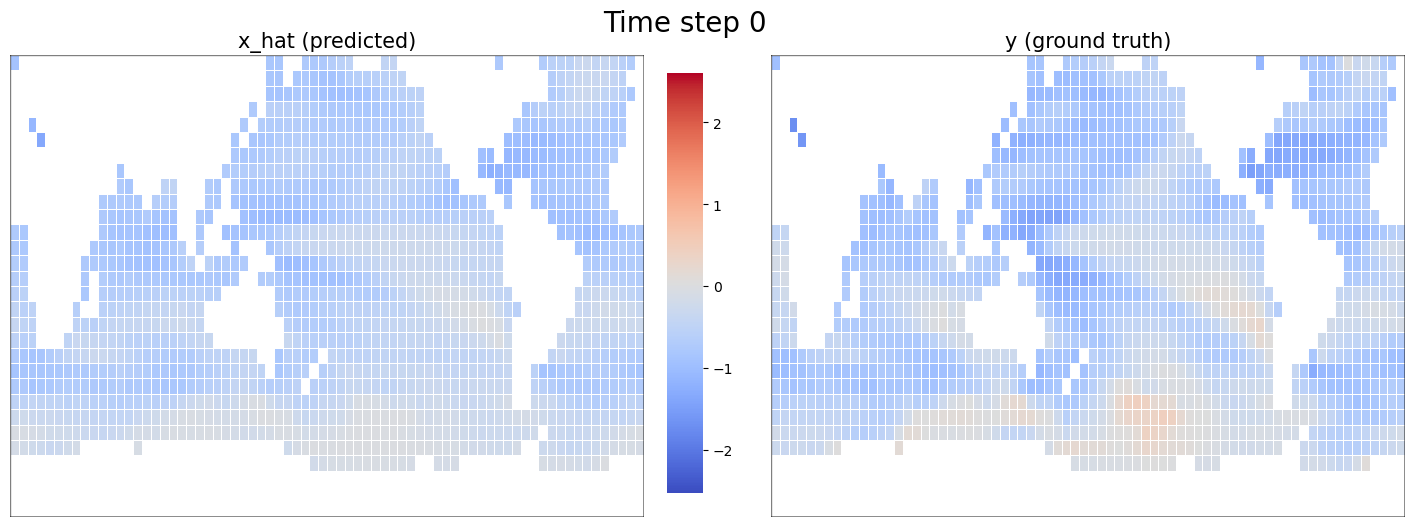

In [17]:
from plots import get_duo_animated_timeserie

a = get_duo_animated_timeserie(x_hat[0], y[0], union_nan_mask)
a.save('compare_pred_and_truth2.gif', writer='pillow', fps=1)

In [19]:
import os
os.environ['PYDEVD_WARN_SLOW_RESOLVE_TIMEOUT']='2'

In [ ]:
"""
TODO :
1)  Créer un LOOCV pour le VAE (en utilisant le même principe que le ridge) - DONE
2)  Jouer un peu avec les paramtètres du VAE (lr, etc...) -> voir quand tu fais du sampling des variables latent, quelle est la tête des timeseries -> créer une animation (matplotlib animation FuncAnimation) - DONE
3)  Faire un CVAE en convulant en espace, pas en temps !
    (utiliser ltsm ou réduire size input à l'avance avec des techniques de réduction de dim -> comment extraire une map de input qui explique le plus le mfr y -> en convulant en espace ?)
4)  Pouvoir faire un confidence interval en samplant par ex. 10 images avec le decoder pour voir la performance du modèle
    Obtenir le mean et le logvar depuis le encoder, sample plusieurs z (page 13, équation 1.22) pour ensuite faire un confidence interval.
5)  Faire un script sans standardization (juste centrer en temps les données)
6)  Investiguer le timeVAE
"""

In [ ]:
"""
1) Extract principal components from the the weight matrix 

(on pourrait dire que reduire le rank on ne perd pas bcp d'accuracy)
"""

In [ ]:
# Specify parameters
epochs = 1
batch_size = 16
lr = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

model = VAE(input_dim=44472, hidden_dim=500, latent_dim=100).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

ith = 1

print('Begin cross validation...\n')

mse_losses, nmse_losses = VAE_LOOCV(cope_data, union_nan_mask, model, epochs, batch_size, lr, verbose=True)

print(f'Finished !')

ith += 1

print('\nFinished training !\n')

Using device: cpu
Begin cross validation...

Epoch 1 complete ! 	Average training loss:  10413.172678392986
[1/29] For eval model ICON-ESM-LR, 	 MSE is 8194.85, 	 NMSE is 131392.61
Epoch 1 complete ! 	Average training loss:  5664.426332019624
[2/29] For eval model EC-Earth3, 	 MSE is 7678.19, 	 NMSE is 266390.03
Epoch 1 complete ! 	Average training loss:  4556.8239339192705
[3/29] For eval model CMCC-CM2-SR5, 	 MSE is 9406.98, 	 NMSE is 163113.19


KeyboardInterrupt: 

In [23]:
n_samples = 5

model.eval()
with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_dataloader):
        x = x.to(device)[0]
        samples = model.sample(x, n_samples)

        break

In [25]:
len(samples)

5

In [24]:
samples[0].shape

torch.Size([44472])